# Audit du pipeline `build_iris_final.py`
# Traçage précis des données disponibles à chaque étape, fallback commune, imputation ML

Ce notebook reproduit le pipeline étape par étape en auditant **à chaque stage** :
- Combien d'IRIS ont des données valides pour chaque variable clé
- Quel % de la population totale ça couvre
- Ce que chaque étape apporte (gain brut)

**Étapes :**
1. Chargement des sources (Census, FILO IRIS, FILO commune)
2. Audit post-fusion avant fallback commune
3. Audit du fallback commune (variables DISP_*)
4. Audit post-imputation ML
5. Visualisation distributions : vraies données vs données imputées

In [1]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch

pd.set_option('display.float_format', lambda x: f'{x:.3f}')
pd.set_option('display.max_columns', 40)

PATH_IRIS = "iris/"
PATH_COMMUNE = "communes/"

def read_insee(filepath, dtype_dict=None):
    try:
        return pd.read_csv(filepath, sep=";", encoding='utf-8', dtype=dtype_dict, low_memory=False)
    except UnicodeDecodeError:
        return pd.read_csv(filepath, sep=";", encoding='latin1', dtype=dtype_dict, low_memory=False)

print("Imports OK")

Imports OK


## Utilitaire d'audit : coverage par variable

Fonction centrale qui calcule pour chaque variable : nb d'IRIS valides, % pop couverte.

In [2]:
def audit_coverage(df, vars_to_check, pop_col=None, label=""):
    """
    Pour chaque variable dans vars_to_check, affiche :
    - nb IRIS avec donnée valide (non-NaN)
    - % des IRIS totaux
    - % de la population totale couverte (si pop_col fourni)
    
    Retourne un DataFrame de résultats.
    """
    total_iris = len(df)
    total_pop = df[pop_col].sum() if pop_col and pop_col in df.columns else None
    
    rows = []
    for var in vars_to_check:
        if var not in df.columns:
            rows.append({'variable': var, 'n_valid': 0, 'pct_iris': 0.0, 'pct_pop': None, 'status': 'ABSENTE'})
            continue
        mask_valid = df[var].notna()
        n_valid = mask_valid.sum()
        pct_iris = n_valid / total_iris * 100
        
        if pop_col and pop_col in df.columns:
            pop_valide = df.loc[mask_valid, pop_col].sum()
            pct_pop = pop_valide / total_pop * 100 if total_pop and total_pop > 0 else 0.0
        else:
            pct_pop = None
        
        rows.append({
            'variable': var,
            'n_valid': n_valid,
            'pct_iris': round(pct_iris, 1),
            'pct_pop': round(pct_pop, 1) if pct_pop is not None else None,
            'n_missing': total_iris - n_valid,
            'status': 'OK' if n_valid == total_iris else ('PARTIEL' if n_valid > 0 else 'VIDE')
        })
    
    result = pd.DataFrame(rows)
    if label:
        print(f"\n{'='*60}")
        print(f"  AUDIT : {label}  ({total_iris} IRIS)")
        print(f"{'='*60}")
        display(result.sort_values('pct_iris'))
    return result


def audit_gain(df_before, df_after, vars_to_check, pop_col, label_before="avant", label_after="après"):
    """Compare coverage avant/après une étape — montre le gain pour chaque variable."""
    total_iris = len(df_after)
    total_pop = df_after[pop_col].sum() if pop_col in df_after.columns else 1
    
    rows = []
    for var in vars_to_check:
        n_before = df_before[var].notna().sum() if var in df_before.columns else 0
        n_after  = df_after[var].notna().sum()  if var in df_after.columns  else 0
        gain_iris = n_after - n_before
        
        # IRIS qui étaient NaN avant et sont valides après
        if var in df_before.columns and var in df_after.columns:
            newly_filled = df_before[var].isna() & df_after[var].notna()
            pop_gained = df_after.loc[newly_filled, pop_col].sum() if pop_col in df_after.columns else 0
            pct_pop_gained = pop_gained / total_pop * 100
        else:
            pct_pop_gained = 0.0
        
        rows.append({
            'variable': var,
            f'n_{label_before}': n_before,
            f'n_{label_after}': n_after,
            'gain_iris': gain_iris,
            'pct_pop_gagnée': round(pct_pop_gained, 1),
        })
    
    result = pd.DataFrame(rows)
    gained = result[result['gain_iris'] > 0].sort_values('gain_iris', ascending=False)
    print(f"\n  Variables améliorées par l'étape ({len(gained)}/{len(vars_to_check)}) :")
    display(gained)
    return result

print("Utilitaires d'audit définis")

Utilitaires d'audit définis


## Étape 1 : Chargement des sources brutes

In [3]:
# ── Chargement sources Census ──────────────────────────────────────────────────
df_dipl = read_insee(os.path.join(PATH_IRIS, "base-ic-diplomes-formation-2021.CSV"),   {'IRIS': str, 'COM': str})
df_act  = read_insee(os.path.join(PATH_IRIS, "base-ic-activite-residents-2021.CSV"),    {'IRIS': str, 'COM': str})
df_pop  = read_insee(os.path.join(PATH_IRIS, "base-ic-evol-struct-pop-2021.CSV"),       {'IRIS': str, 'COM': str})
df_log  = read_insee(os.path.join(PATH_IRIS, "base-ic-logement-2022.CSV"),              {'IRIS': str, 'COM': str})

# ── FILO IRIS ──────────────────────────────────────────────────────────────────
df_filo_iris = read_insee(os.path.join(PATH_IRIS, "BASE_TD_FILO_IRIS_2021_DISP.csv"),  {'IRIS': str})

# ── FILO Commune (fallback) ────────────────────────────────────────────────────
df_filo_com    = read_insee(os.path.join(PATH_COMMUNE, "FILO2021_DISP_COM.csv"),        {'CODGEO': str})
df_pauvres_com = read_insee(os.path.join(PATH_COMMUNE, "FILO2021_DISP_PAUVRES_COM.csv"),{'CODGEO': str})

# ── BPE ────────────────────────────────────────────────────────────────────────
df_bpe     = read_insee(os.path.join(PATH_IRIS, "ds_bpe_iris_2024_geo_2024.csv"),          {'GEO': str})
df_bpe_edu = read_insee(os.path.join(PATH_IRIS, "ds_bpe_education_iris_2024_geo_2024.csv"),{'GEO': str})
df_bpe_sp  = read_insee(os.path.join(PATH_IRIS, "ds_bpe_sport_culture_iris_2024_geo_2024.csv"), {'GEO': str})

print("Sources chargées :")
print(f"  Diplômes census     : {len(df_dipl):>5} IRIS  × {len(df_dipl.columns)} cols")
print(f"  Activité census     : {len(df_act):>5} IRIS  × {len(df_act.columns)} cols")
print(f"  Population census   : {len(df_pop):>5} IRIS  × {len(df_pop.columns)} cols")
print(f"  Logement 2022       : {len(df_log):>5} IRIS  × {len(df_log.columns)} cols")
print(f"  FILO IRIS           : {len(df_filo_iris):>5} IRIS  × {len(df_filo_iris.columns)} cols")
print(f"  FILO Commune        : {len(df_filo_com):>5} communes × {len(df_filo_com.columns)} cols")
print(f"  FILO Pauvres Commune: {len(df_pauvres_com):>5} communes × {len(df_pauvres_com.columns)} cols")
print(f"  BPE (général)       : {len(df_bpe):>5} lignes")
print(f"  BPE éducation       : {len(df_bpe_edu):>5} lignes")
print(f"  BPE sport/culture   : {len(df_bpe_sp):>5} lignes")

Sources chargées :
  Diplômes census     : 49280 IRIS  × 42 cols
  Activité census     : 49280 IRIS  × 119 cols
  Population census   : 49280 IRIS  × 76 cols
  Logement 2022       : 49276 IRIS  × 101 cols
  FILO IRIS           : 16026 IRIS  × 30 cols
  FILO Commune        : 34929 communes × 732 cols
  FILO Pauvres Commune: 34929 communes × 141 cols
  BPE (général)       : 1233152 lignes
  BPE éducation       : 126517 lignes
  BPE sport/culture   : 403307 lignes


## Étape 2 : Préparation FILO commune + nettoyage

Reproduit exactement la logique de renommage et conversion numérique du script.

In [4]:
# Mapping identique à build_iris_final.py
COM_RENAME_MAP = {
    'Q221': 'DISP_MED21',    'TP6021': 'DISP_TP6021',  'PACT21': 'DISP_PACT21',
    'PPAT21': 'DISP_PPAT21', 'PPSOC21': 'DISP_PPSOC21','PIMPOT21': 'DISP_PIMPOT21',
    'Q121': 'DISP_Q121',     'Q321': 'DISP_Q321',       'Q3_Q1': 'DISP_EQ21',
    'RD': 'DISP_RD21',       'D121': 'DISP_D121',       'D221': 'DISP_D221',
    'D321': 'DISP_D321',     'D421': 'DISP_D421',       'D621': 'DISP_D621',
    'D721': 'DISP_D721',     'D821': 'DISP_D821',       'D921': 'DISP_D921',
    'S80S2021': 'DISP_S80S2021', 'GI21': 'DISP_GI21',
    'PTSA21': 'DISP_PTSA21', 'PCHO21': 'DISP_PCHO21',  'PBEN21': 'DISP_PBEN21',
    'PPEN21': 'DISP_PPEN21', 'PPFAM21': 'DISP_PPFAM21','PPMINI21': 'DISP_PPMINI21',
    'PPLOGT21': 'DISP_PPLOGT21',
}
COLS_TO_FILL = list(COM_RENAME_MAP.values())

# Fusionner commune + pauvres
df_com_full = pd.merge(df_filo_com, df_pauvres_com, on='CODGEO', how='left')
df_com_full.rename(columns=COM_RENAME_MAP, inplace=True)

# Conversion numérique (INSEE utilise ',' comme séparateur décimal + valeurs 'nd','ns','s')
for col in COLS_TO_FILL:
    if col in df_com_full.columns and not pd.api.types.is_numeric_dtype(df_com_full[col]):
        df_com_full[col] = (df_com_full[col].astype(str)
                            .str.replace(',', '.')
                            .replace(['nd', 'ns', 's', 'nan', 'None'], np.nan))
        df_com_full[col] = pd.to_numeric(df_com_full[col], errors='coerce')

# Nettoyer FILO IRIS (même logique)
filo_cols = [c for c in df_filo_iris.columns if c != 'IRIS']
for col in filo_cols:
    if not pd.api.types.is_numeric_dtype(df_filo_iris[col]):
        df_filo_iris[col] = (df_filo_iris[col].astype(str)
                             .str.replace(',', '.')
                             .replace(['nd', 'ns', 's', 'nan', 'None'], np.nan))
        df_filo_iris[col] = pd.to_numeric(df_filo_iris[col], errors='coerce')

# Audit coverage FILO commune
print("Coverage FILO commune (source de fallback) :")
cov_com = {}
for col in COLS_TO_FILL:
    if col in df_com_full.columns:
        n_val = df_com_full[col].notna().sum()
        cov_com[col] = n_val / len(df_com_full) * 100
        
df_cov_com = pd.DataFrame([(k, f"{v:.1f}%") for k, v in cov_com.items()], columns=['variable_DISP', 'pct_communes_valides'])
display(df_cov_com)

print(f"\nFILO commune : {len(df_com_full)} communes")
print(f"FILO IRIS    : {len(df_filo_iris)} IRIS")

# Audit NaN dans FILO IRIS avant fusion
print("\nCoverage FILO IRIS brut (variables DISP_*) :")
disp_cols_iris = [c for c in df_filo_iris.columns if c.startswith('DISP_')]
cov_iris_rows = []
for col in disp_cols_iris:
    n_val = df_filo_iris[col].notna().sum()
    cov_iris_rows.append({'variable': col, 'n_valid': n_val, 'pct_iris': round(n_val/len(df_filo_iris)*100, 1)})
df_cov_iris_raw = pd.DataFrame(cov_iris_rows).sort_values('pct_iris')
display(df_cov_iris_raw)

Coverage FILO commune (source de fallback) :


,variable_DISP,pct_communes_valides
0,DISP_MED21,89.7%
1,DISP_TP6021,12.6%
2,DISP_PACT21,15.3%
3,DISP_PPAT21,15.3%
4,DISP_PPSOC21,15.3%
5,DISP_PIMPOT21,15.3%
6,DISP_Q121,15.3%
7,DISP_Q321,15.3%
8,DISP_EQ21,15.3%
9,DISP_RD21,15.3%



FILO commune : 34929 communes
FILO IRIS    : 16026 IRIS

Coverage FILO IRIS brut (variables DISP_*) :


,variable,n_valid,pct_iris
18,DISP_PTSA21,14266,89.000
20,DISP_PBEN21,14266,89.000
19,DISP_PCHO21,14266,89.000
0,DISP_TP6021,14486,90.400
4,DISP_Q321,14490,90.400
1,DISP_INCERT21,14490,90.400
2,DISP_Q121,14490,90.400
3,DISP_MED21,14490,90.400
8,DISP_D321,14490,90.400
9,DISP_D421,14490,90.400


## Étape 3 : Fusion Census (diplômes + activité + population + logement + BPE)

In [5]:
# ── Fusion Census (identique build_iris_final.py) ─────────────────────────────
df_pop['IRIS'] = df_pop['IRIS'].astype(str).str.zfill(9)
df_log['IRIS'] = df_log['IRIS'].astype(str).str.zfill(9)

merged = pd.merge(df_dipl, df_act.drop(columns=['COM','TYP_IRIS','LAB_IRIS'], errors='ignore'), on='IRIS', how='outer')

existing = set(merged.columns) - {'IRIS'}
pop_drop = [c for c in df_pop.columns if c in existing or c in ('COM','TYP_IRIS','LAB_IRIS')]
merged = pd.merge(merged, df_pop.drop(columns=pop_drop, errors='ignore'), on='IRIS', how='outer')

existing = set(merged.columns) - {'IRIS'}
log_drop = [c for c in df_log.columns if c in existing or c in ('COM','TYP_IRIS','LAB_IRIS')]
merged = pd.merge(merged, df_log.drop(columns=log_drop, errors='ignore'), on='IRIS', how='outer')

# ── BPE général ────────────────────────────────────────────────────────────────
df_bpe.rename(columns={'GEO': 'IRIS'}, inplace=True)
df_bpe['IRIS'] = df_bpe['IRIS'].astype(str).str.zfill(9)
DOM_NAMES = {'A':'services','B':'commerces','C':'enseignement','D':'sante','E':'transports','F':'sports_culture','G':'tourisme'}
bpe_domain = df_bpe.groupby(['IRIS','FACILITY_DOM'])['OBS_VALUE'].sum().unstack(fill_value=0)
bpe_domain.columns = [f'bpe_{k}_{DOM_NAMES[k]}' for k in bpe_domain.columns]
bpe_domain['bpe_total'] = bpe_domain.sum(axis=1)
bpe_domain = bpe_domain.reset_index()
merged = pd.merge(merged, bpe_domain, on='IRIS', how='left')
bpe_cols = [c for c in merged.columns if c.startswith('bpe_')]
merged[bpe_cols] = merged[bpe_cols].fillna(0)

# ── BPE éducation ──────────────────────────────────────────────────────────────
df_bpe_edu.rename(columns={'GEO': 'IRIS'}, inplace=True)
df_bpe_edu['IRIS'] = df_bpe_edu['IRIS'].astype(str).str.zfill(9)
bpe_ep = df_bpe_edu[df_bpe_edu['EP'].astype(str) == '1'].groupby('IRIS')['OBS_VALUE'].sum().rename('bpe_educ_prioritaire')
bpe_pr = df_bpe_edu[df_bpe_edu['SCHOOL_SECTOR'].astype(str) == 'PR'].groupby('IRIS')['OBS_VALUE'].sum().rename('bpe_ecole_privee')
merged = merged.join(bpe_ep, on='IRIS', how='left')
merged = merged.join(bpe_pr, on='IRIS', how='left')
merged[['bpe_educ_prioritaire','bpe_ecole_privee']] = merged[['bpe_educ_prioritaire','bpe_ecole_privee']].fillna(0)

# ── BPE sport/culture ──────────────────────────────────────────────────────────
df_bpe_sp.rename(columns={'GEO': 'IRIS'}, inplace=True)
df_bpe_sp['IRIS'] = df_bpe_sp['IRIS'].astype(str).str.zfill(9)
df_sport = df_bpe_sp[df_bpe_sp['FACILITY_SDOM'].isin(['F1','F2'])]
bpe_indoor = df_sport[df_sport['INDOOR'].astype(str) == '1'].groupby('IRIS')['OBS_VALUE'].sum().rename('bpe_sport_indoor')
bpe_access = df_sport[df_sport['PRACTICE_AREA_ACCESSIBILITY'].astype(str) == '1'].groupby('IRIS')['OBS_VALUE'].sum().rename('bpe_sport_accessible')
bpe_sport_tot = df_sport.groupby('IRIS')['OBS_VALUE'].sum().rename('bpe_sport_total')
merged = merged.join(bpe_indoor, on='IRIS', how='left')
merged = merged.join(bpe_access, on='IRIS', how='left')
merged = merged.join(bpe_sport_tot, on='IRIS', how='left')
merged[['bpe_sport_indoor','bpe_sport_accessible','bpe_sport_total']] = merged[['bpe_sport_indoor','bpe_sport_accessible','bpe_sport_total']].fillna(0)

print(f"Après fusion Census + BPE : {len(merged)} IRIS × {len(merged.columns)} colonnes")

# Quelques variables clés Census pour vérifier
KEY_CENSUS_VARS = ['P21_POP', 'P21_ACT1564', 'P21_NSCOL15P', 'C21_POP15P',
                   'P22_RP', 'P22_RP_PROP', 'C21_ACTOCC15P_VOIT', 'bpe_total']

print(f"\nCoverage variables Census clés (population proxy = P21_POP) :")
for var in KEY_CENSUS_VARS:
    if var in merged.columns:
        n = merged[var].notna().sum()
        print(f"  {var:<35}: {n}/{len(merged)} IRIS ({n/len(merged)*100:.1f}%)")

Après fusion Census + BPE : 49303 IRIS × 336 colonnes

Coverage variables Census clés (population proxy = P21_POP) :
  P21_POP                            : 49280/49303 IRIS (100.0%)
  P21_ACT1564                        : 49280/49303 IRIS (100.0%)
  P21_NSCOL15P                       : 49280/49303 IRIS (100.0%)
  C21_POP15P                         : 49280/49303 IRIS (100.0%)
  P22_RP                             : 49276/49303 IRIS (99.9%)
  P22_RP_PROP                        : 49276/49303 IRIS (99.9%)
  C21_ACTOCC15P_VOIT                 : 49280/49303 IRIS (100.0%)
  bpe_total                          : 49303/49303 IRIS (100.0%)


## Étape 4 : Fusion FILO IRIS — audit avant fallback commune

In [6]:
# Fusion FILO IRIS (left join sur Census)
final_pre_fallback = pd.merge(merged, df_filo_iris, on='IRIS', how='left')
print(f"Après fusion FILO IRIS : {len(final_pre_fallback)} IRIS × {len(final_pre_fallback.columns)} colonnes")

# Pour l'audit pop, utiliser P21_POP
pop_col_audit = 'P21_POP'
total_pop = final_pre_fallback[pop_col_audit].sum()
print(f"  Population totale : {total_pop:,.0f}")

# Audit complet des variables DISP_ AVANT fallback commune
print(f"\n{'='*65}")
print("  AUDIT DISP_* après fusion FILO IRIS — AVANT fallback commune")
print(f"{'='*65}")

rows_pre = []
for col in COLS_TO_FILL:
    if col in final_pre_fallback.columns:
        mask = final_pre_fallback[col].notna()
        n = mask.sum()
        pop_ok = final_pre_fallback.loc[mask, pop_col_audit].sum()
        rows_pre.append({
            'variable': col,
            'n_iris_valides': n,
            'n_iris_manquants': len(final_pre_fallback) - n,
            'pct_iris': round(n / len(final_pre_fallback) * 100, 1),
            'pct_pop': round(pop_ok / total_pop * 100, 1),
        })
    else:
        rows_pre.append({'variable': col, 'n_iris_valides': 0, 'n_iris_manquants': len(final_pre_fallback), 'pct_iris': 0.0, 'pct_pop': 0.0})

df_pre = pd.DataFrame(rows_pre).sort_values('pct_iris')
display(df_pre)

Après fusion FILO IRIS : 49303 IRIS × 365 colonnes
  Population totale : 67,408,052

  AUDIT DISP_* après fusion FILO IRIS — AVANT fallback commune


,variable,n_iris_valides,n_iris_manquants,pct_iris,pct_pop
22,DISP_PBEN21,14266,35037,28.900,56.600
20,DISP_PTSA21,14266,35037,28.900,56.600
21,DISP_PCHO21,14266,35037,28.900,56.600
0,DISP_MED21,14490,34813,29.400,57.200
4,DISP_PPSOC21,14490,34813,29.400,57.200
1,DISP_TP6021,14486,34817,29.400,57.200
2,DISP_PACT21,14490,34813,29.400,57.200
3,DISP_PPAT21,14490,34813,29.400,57.200
8,DISP_EQ21,14490,34813,29.400,57.200
9,DISP_RD21,14490,34813,29.400,57.200


## Étape 5 : Application du fallback commune — vérification de la logique

Audit détaillé : pour chaque IRIS, d'où vient la valeur finale — IRIS direct ou fallback commune ?

In [7]:
# Fusion avec fallback commune (identique build_iris_final.py)
# On garde les _x et _y séparément pour auditer avant le fillna
final_with_com = pd.merge(
    final_pre_fallback,
    df_com_full[['CODGEO'] + COLS_TO_FILL],
    left_on='COM', right_on='CODGEO', how='left'
)

# Audit source par variable : pour chaque IRIS, la valeur vient de IRIS (_x) ou commune (_y) ?
print(f"{'='*70}")
print("  AUDIT FALLBACK COMMUNE : origine des données DISP_* par variable")
print(f"{'='*70}")
print(f"  (Total IRIS : {len(final_with_com)})")

fallback_audit = []
for col in COLS_TO_FILL:
    col_x = col + '_x'  # valeur IRIS
    col_y = col + '_y'  # valeur commune (fallback)
    
    if col_x not in final_with_com.columns or col_y not in final_with_com.columns:
        continue
    
    iris_has_data   = final_with_com[col_x].notna()
    com_has_data    = final_with_com[col_y].notna()
    both_null       = ~iris_has_data & ~com_has_data
    iris_only       = iris_has_data
    fallback_used   = ~iris_has_data & com_has_data
    
    n_iris_direct  = iris_has_data.sum()
    n_fallback     = fallback_used.sum()
    n_toujours_nan = both_null.sum()
    n_total_apres  = n_iris_direct + n_fallback
    
    pop_iris_direct = final_with_com.loc[iris_has_data, pop_col_audit].sum()
    pop_fallback    = final_with_com.loc[fallback_used, pop_col_audit].sum()
    pop_nan         = final_with_com.loc[both_null, pop_col_audit].sum()
    
    fallback_audit.append({
        'variable': col,
        'n_iris_direct':  n_iris_direct,
        'n_fallback_com': n_fallback,
        'n_toujours_nan': n_toujours_nan,
        'pct_iris_direct': round(n_iris_direct / len(final_with_com) * 100, 1),
        'pct_fallback':    round(n_fallback / len(final_with_com) * 100, 1),
        'pct_nan_final':   round(n_toujours_nan / len(final_with_com) * 100, 1),
        'pct_pop_direct':  round(pop_iris_direct / total_pop * 100, 1),
        'pct_pop_fallback':round(pop_fallback / total_pop * 100, 1),
        'pct_pop_nan':     round(pop_nan / total_pop * 100, 1),
    })

df_fallback_audit = pd.DataFrame(fallback_audit)
display(df_fallback_audit.sort_values('pct_nan_final', ascending=False))

# Résumé global
print(f"\n--- Résumé ---")
for _, row in df_fallback_audit.iterrows():
    if row['n_fallback_com'] > 0:
        print(f"  {row['variable']:<25}: {row['n_fallback_com']:>4} IRIS bouchés via commune ({row['pct_fallback']:.1f}% IRIS, {row['pct_pop_fallback']:.1f}% pop) | encore NaN: {row['n_toujours_nan']} IRIS ({row['pct_nan_final']:.1f}%)")

  AUDIT FALLBACK COMMUNE : origine des données DISP_* par variable
  (Total IRIS : 49303)


,variable,n_iris_direct,n_fallback_com,n_toujours_nan,pct_iris_direct,pct_fallback,pct_nan_final,pct_pop_direct,pct_pop_fallback,pct_pop_nan
1,DISP_TP6021,14486,4054,30763,29.400,8.200,62.400,57.200,15.500,27.300
2,DISP_PACT21,14490,4999,29814,29.400,10.100,60.500,57.200,19.200,23.700
3,DISP_PPAT21,14490,4999,29814,29.400,10.100,60.500,57.200,19.200,23.700
7,DISP_Q321,14490,4999,29814,29.400,10.100,60.500,57.200,19.200,23.700
4,DISP_PPSOC21,14490,4999,29814,29.400,10.100,60.500,57.200,19.200,23.700
5,DISP_PIMPOT21,14490,4999,29814,29.400,10.100,60.500,57.200,19.200,23.700
6,DISP_Q121,14490,4999,29814,29.400,10.100,60.500,57.200,19.200,23.700
9,DISP_RD21,14490,4999,29814,29.400,10.100,60.500,57.200,19.200,23.700
8,DISP_EQ21,14490,4999,29814,29.400,10.100,60.500,57.200,19.200,23.700
10,DISP_D121,14490,4999,29814,29.400,10.100,60.500,57.200,19.200,23.700



--- Résumé ---
  DISP_MED21               : 30968 IRIS bouchés via commune (62.8% IRIS, 41.5% pop) | encore NaN: 3845 IRIS (7.8%)
  DISP_TP6021              : 4054 IRIS bouchés via commune (8.2% IRIS, 15.5% pop) | encore NaN: 30763 IRIS (62.4%)
  DISP_PACT21              : 4999 IRIS bouchés via commune (10.1% IRIS, 19.2% pop) | encore NaN: 29814 IRIS (60.5%)
  DISP_PPAT21              : 4999 IRIS bouchés via commune (10.1% IRIS, 19.2% pop) | encore NaN: 29814 IRIS (60.5%)
  DISP_PPSOC21             : 4999 IRIS bouchés via commune (10.1% IRIS, 19.2% pop) | encore NaN: 29814 IRIS (60.5%)
  DISP_PIMPOT21            : 4999 IRIS bouchés via commune (10.1% IRIS, 19.2% pop) | encore NaN: 29814 IRIS (60.5%)
  DISP_Q121                : 4999 IRIS bouchés via commune (10.1% IRIS, 19.2% pop) | encore NaN: 29814 IRIS (60.5%)
  DISP_Q321                : 4999 IRIS bouchés via commune (10.1% IRIS, 19.2% pop) | encore NaN: 29814 IRIS (60.5%)
  DISP_EQ21                : 4999 IRIS bouchés via commune

## Vérification sanity check : cohérence des valeurs fallback commune vs IRIS

Quand les deux sont disponibles, est-ce que les valeurs IRIS et commune sont cohérentes ?
(Un écart systématique révèlerait un problème de mapping ou d'agrégation.)

In [8]:
print("Sanity check : corrélation IRIS vs commune quand les deux sont disponibles")
print("(Si la corrélation est faible, le fallback est biaisé)\n")

sanity_rows = []
for col in COLS_TO_FILL:
    col_x = col + '_x'
    col_y = col + '_y'
    if col_x not in final_with_com.columns or col_y not in final_with_com.columns:
        continue
    
    both_valid = final_with_com[col_x].notna() & final_with_com[col_y].notna()
    n_both = both_valid.sum()
    if n_both < 5:
        sanity_rows.append({'variable': col, 'n_cas_double': n_both, 'corr': None, 'mae': None, 'biais_moyen': None})
        continue
    
    iris_vals = final_with_com.loc[both_valid, col_x]
    com_vals  = final_with_com.loc[both_valid, col_y]
    
    corr = iris_vals.corr(com_vals)
    mae  = (iris_vals - com_vals).abs().mean()
    biais = (iris_vals - com_vals).mean()  # positif = IRIS > commune en moyenne
    
    sanity_rows.append({
        'variable': col,
        'n_cas_double': n_both,
        'corr_iris_vs_com': round(corr, 3),
        'MAE': round(mae, 3),
        'biais_moyen_iris_minus_com': round(biais, 3),
    })

df_sanity = pd.DataFrame(sanity_rows).sort_values('corr_iris_vs_com')
display(df_sanity)

# Visualiser les cas où corrélation < 0.7 (potentiellement problématiques)
bad = df_sanity[df_sanity['corr_iris_vs_com'] < 0.7]
if len(bad) > 0:
    print(f"\n⚠️  Variables avec corrélation IRIS/commune < 0.7 ({len(bad)} variables) :")
    display(bad)
else:
    print("\nToutes les variables ont une corrélation IRIS/commune >= 0.7 — fallback cohérent.")

Sanity check : corrélation IRIS vs commune quand les deux sont disponibles
(Si la corrélation est faible, le fallback est biaisé)



,variable,n_cas_double,corr_iris_vs_com,MAE,biais_moyen_iris_minus_com
26,DISP_PPLOGT21,14490,0.629,0.742,0.186
24,DISP_PPFAM21,14490,0.637,0.861,0.206
4,DISP_PPSOC21,14490,0.638,3.089,0.812
25,DISP_PPMINI21,14490,0.654,1.586,0.420
22,DISP_PBEN21,14266,0.657,1.626,-0.270
1,DISP_TP6021,14482,0.679,6.212,0.210
8,DISP_EQ21,14490,0.684,15256.016,-15256.016
21,DISP_PCHO21,14266,0.689,0.584,0.092
10,DISP_D121,14490,0.732,1397.757,489.055
11,DISP_D221,14490,0.742,1866.742,567.663



⚠️  Variables avec corrélation IRIS/commune < 0.7 (8 variables) :


,variable,n_cas_double,corr_iris_vs_com,MAE,biais_moyen_iris_minus_com
26,DISP_PPLOGT21,14490,0.629,0.742,0.186
24,DISP_PPFAM21,14490,0.637,0.861,0.206
4,DISP_PPSOC21,14490,0.638,3.089,0.812
25,DISP_PPMINI21,14490,0.654,1.586,0.420
22,DISP_PBEN21,14266,0.657,1.626,-0.270
1,DISP_TP6021,14482,0.679,6.212,0.210
8,DISP_EQ21,14490,0.684,15256.016,-15256.016
21,DISP_PCHO21,14266,0.689,0.584,0.092


## Scatter IRIS vs commune pour les variables clés

Visualise la cohérence du fallback : chaque point = un IRIS qui a les deux valeurs.

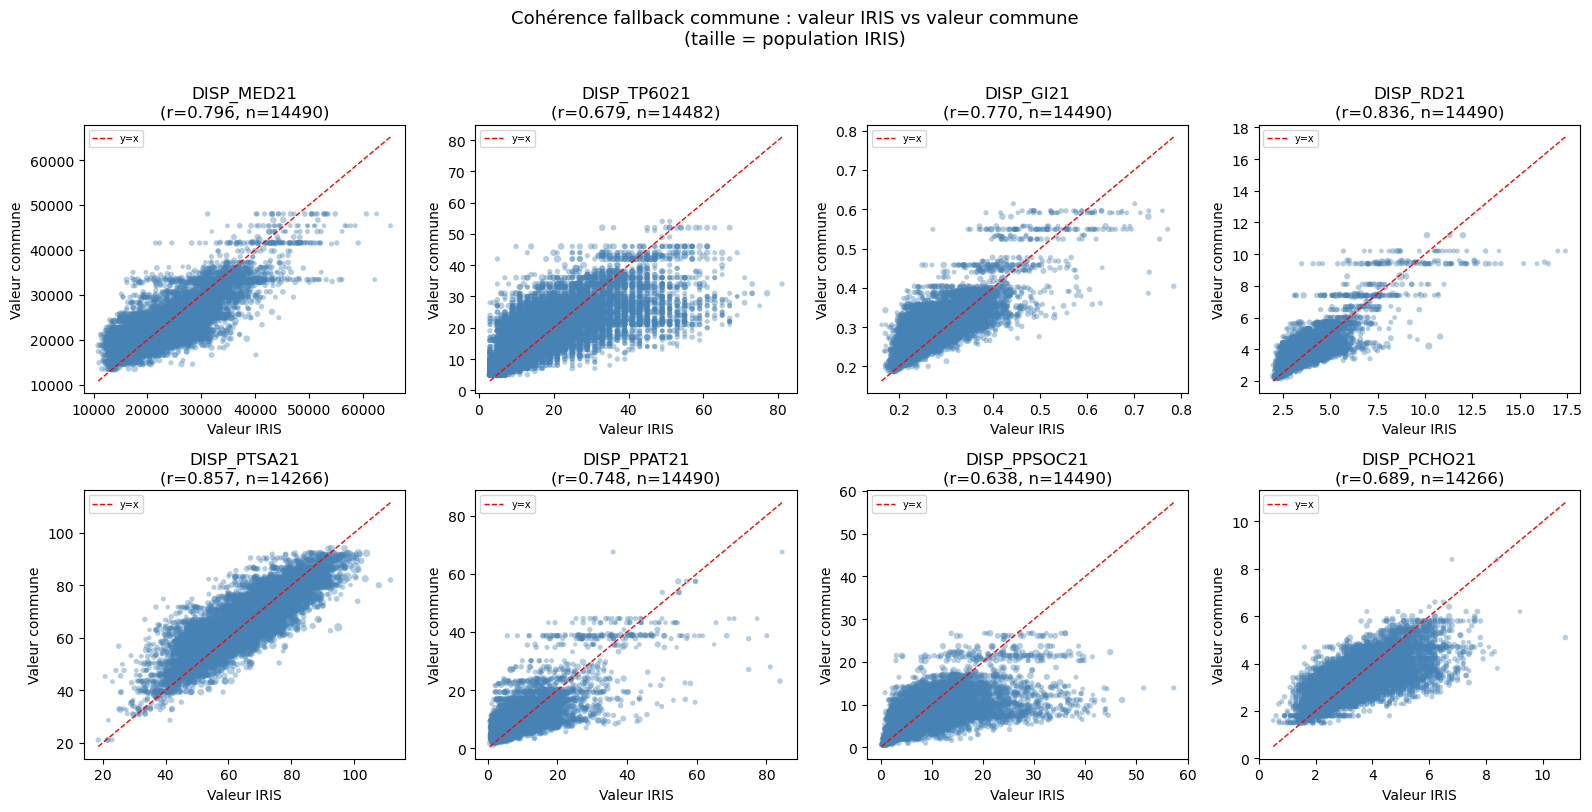

In [9]:
KEY_DISP_VARS = ['DISP_MED21', 'DISP_TP6021', 'DISP_GI21', 'DISP_RD21',
                 'DISP_PTSA21', 'DISP_PPAT21', 'DISP_PPSOC21', 'DISP_PCHO21']

n_cols = 4
n_rows = (len(KEY_DISP_VARS) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(KEY_DISP_VARS):
    ax = axes[i]
    col_x = col + '_x'
    col_y = col + '_y'
    if col_x not in final_with_com.columns or col_y not in final_with_com.columns:
        ax.set_title(f"{col}\n(absent)")
        continue
    
    both = final_with_com[[col_x, col_y, pop_col_audit]].dropna()
    if len(both) < 2:
        ax.set_title(f"{col}\n(insuffisant)")
        continue
    
    corr = both[col_x].corr(both[col_y])
    
    # Taille = population
    pop_norm = (both[pop_col_audit] / both[pop_col_audit].max() * 60 + 5).clip(5, 80)
    ax.scatter(both[col_x], both[col_y], s=pop_norm, alpha=0.4, color='steelblue', edgecolors='none')
    
    # Ligne de référence y=x
    mn = min(both[col_x].min(), both[col_y].min())
    mx = max(both[col_x].max(), both[col_y].max())
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1, label='y=x')
    
    ax.set_xlabel('Valeur IRIS')
    ax.set_ylabel('Valeur commune')
    ax.set_title(f"{col}\n(r={corr:.3f}, n={len(both)})")
    ax.legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Cohérence fallback commune : valeur IRIS vs valeur commune\n(taille = population IRIS)", 
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Étape 6 : Application du fillna + état final post-fallback commune

In [10]:
# Application du fillna (identique build_iris_final.py)
final_post_fallback = final_with_com.copy()
for col in COLS_TO_FILL:
    col_x = col + '_x'
    col_y = col + '_y'
    if col_x in final_post_fallback.columns and col_y in final_post_fallback.columns:
        final_post_fallback[col] = final_post_fallback[col_x].fillna(final_post_fallback[col_y])
        final_post_fallback.drop(columns=[col_x, col_y], inplace=True)

final_post_fallback.drop(columns=['CODGEO'], errors='ignore', inplace=True)

# Audit post-fallback
print(f"{'='*65}")
print("  AUDIT DISP_* APRÈS fallback commune")
print(f"{'='*65}")

rows_post = []
for col in COLS_TO_FILL:
    if col in final_post_fallback.columns:
        mask = final_post_fallback[col].notna()
        n = mask.sum()
        pop_ok = final_post_fallback.loc[mask, pop_col_audit].sum()
        rows_post.append({
            'variable': col,
            'n_iris_valides': n,
            'n_iris_manquants': len(final_post_fallback) - n,
            'pct_iris': round(n / len(final_post_fallback) * 100, 1),
            'pct_pop': round(pop_ok / total_pop * 100, 1),
        })
df_post = pd.DataFrame(rows_post).sort_values('pct_iris')
display(df_post)

# Gain par l'étape fallback
print(f"\n{'='*65}")
print("  GAIN apporté par le fallback commune")
print(f"{'='*65}")
df_pre_idx = df_pre.set_index('variable')
df_post_idx = df_post.set_index('variable')
gain_rows = []
for col in COLS_TO_FILL:
    if col in df_pre_idx.index and col in df_post_idx.index:
        n_pre  = df_pre_idx.loc[col, 'n_iris_valides']
        n_post = df_post_idx.loc[col, 'n_iris_valides']
        gain = n_post - n_pre
        gain_rows.append({
            'variable': col,
            'avant': n_pre,
            'après': n_post,
            'gain_iris': gain,
            'pct_iris_avant': df_pre_idx.loc[col, 'pct_iris'],
            'pct_iris_après': df_post_idx.loc[col, 'pct_iris'],
            'gain_pct_iris': round(df_post_idx.loc[col, 'pct_iris'] - df_pre_idx.loc[col, 'pct_iris'], 1),
        })

df_gain = pd.DataFrame(gain_rows).sort_values('gain_iris', ascending=False)
display(df_gain[df_gain['gain_iris'] > 0])

  AUDIT DISP_* APRÈS fallback commune


,variable,n_iris_valides,n_iris_manquants,pct_iris,pct_pop
1,DISP_TP6021,18540,30763,37.600,72.700
2,DISP_PACT21,19489,29814,39.500,76.300
3,DISP_PPAT21,19489,29814,39.500,76.300
4,DISP_PPSOC21,19489,29814,39.500,76.300
6,DISP_Q121,19489,29814,39.500,76.300
5,DISP_PIMPOT21,19489,29814,39.500,76.300
7,DISP_Q321,19489,29814,39.500,76.300
8,DISP_EQ21,19489,29814,39.500,76.300
12,DISP_D321,19489,29814,39.500,76.300
9,DISP_RD21,19489,29814,39.500,76.300



  GAIN apporté par le fallback commune


,variable,avant,après,gain_iris,pct_iris_avant,pct_iris_après,gain_pct_iris
0,DISP_MED21,14490,45458,30968,29.400,92.200,62.800
22,DISP_PBEN21,14266,19489,5223,28.900,39.500,10.600
21,DISP_PCHO21,14266,19489,5223,28.900,39.500,10.600
20,DISP_PTSA21,14266,19489,5223,28.900,39.500,10.600
7,DISP_Q321,14490,19489,4999,29.400,39.500,10.100
5,DISP_PIMPOT21,14490,19489,4999,29.400,39.500,10.100
6,DISP_Q121,14490,19489,4999,29.400,39.500,10.100
9,DISP_RD21,14490,19489,4999,29.400,39.500,10.100
4,DISP_PPSOC21,14490,19489,4999,29.400,39.500,10.100
2,DISP_PACT21,14490,19489,4999,29.400,39.500,10.100


## Étape 7 : Imputation ML — reproductibilité + audit

Reproduit exactement l'étape ML de `build_iris_final.py` et trace ce qui est imputé, accepté, rejeté.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# ── Préparation features (identique build_iris_final.py) ──────────────────────
df_ml = final_post_fallback.copy()
df_num = df_ml.select_dtypes(include=['int16','int32','int64','float16','float32','float64']).copy()

if 'P21_ACT1564' in df_num.columns:
    for c in [col for col in df_num.columns if col.startswith('C21_ACT1564_CS')]:
        df_num[f"PCT_{c}"] = (df_num[c] / df_num['P21_ACT1564']) * 100

if 'P21_POP1564' in df_num.columns:
    for c in [col for col in df_num.columns if col.startswith('P21_NSCOL15P')]:
        df_num[f"PCT_{c}"] = (df_num[c] / df_num['P21_POP1564']) * 100

df_num = df_num.replace([np.inf, -np.inf], np.nan)

# Détection cibles (variables avec >10% de NaN et commençant par DISP_)
missing_pct = (df_num.isna().sum() / len(df_num)) * 100
vars_cibles = missing_pct[(missing_pct > 10) & (missing_pct.index.str.startswith('DISP_'))].index.tolist()
print(f"Variables cibles détectées (>10% NaN, DISP_*) : {len(vars_cibles)}")
for v in sorted(vars_cibles):
    print(f"  {v}: {missing_pct[v]:.1f}% NaN ({int(missing_pct[v]/100 * len(df_num))} IRIS)")

cols_a_exclure = [c for c in df_num.columns if c.startswith('DISP_') and c != 'DISP_MED21']
X_cols = [c for c in df_num.columns if c not in vars_cibles and c not in cols_a_exclure]
print(f"\nFeatures disponibles pour ML : {len(X_cols)}")

Variables cibles détectées (>10% NaN, DISP_*) : 28
  DISP_D121: 60.5% NaN (29814 IRIS)
  DISP_D221: 60.5% NaN (29814 IRIS)
  DISP_D321: 60.5% NaN (29814 IRIS)
  DISP_D421: 60.5% NaN (29814 IRIS)
  DISP_D621: 60.5% NaN (29814 IRIS)
  DISP_D721: 60.5% NaN (29814 IRIS)
  DISP_D821: 60.5% NaN (29814 IRIS)
  DISP_D921: 60.5% NaN (29814 IRIS)
  DISP_EQ21: 60.5% NaN (29814 IRIS)
  DISP_GI21: 60.5% NaN (29814 IRIS)
  DISP_INCERT21: 70.6% NaN (34813 IRIS)
  DISP_NOTE21: 70.4% NaN (34731 IRIS)
  DISP_PACT21: 60.5% NaN (29814 IRIS)
  DISP_PBEN21: 60.5% NaN (29814 IRIS)
  DISP_PCHO21: 60.5% NaN (29814 IRIS)
  DISP_PIMPOT21: 60.5% NaN (29814 IRIS)
  DISP_PPAT21: 60.5% NaN (29814 IRIS)
  DISP_PPEN21: 60.5% NaN (29814 IRIS)
  DISP_PPFAM21: 60.5% NaN (29814 IRIS)
  DISP_PPLOGT21: 60.5% NaN (29814 IRIS)
  DISP_PPMINI21: 60.5% NaN (29814 IRIS)
  DISP_PPSOC21: 60.5% NaN (29814 IRIS)
  DISP_PTSA21: 60.5% NaN (29814 IRIS)
  DISP_Q121: 60.5% NaN (29814 IRIS)
  DISP_Q321: 60.5% NaN (29814 IRIS)
  DISP_RD21: 

In [15]:
# ── Entraînement ML — audit complet ──────────────────────────────────────────
r2_threshold   = 0.73
corr_threshold = 0.80
err_threshold  = 25.0

df_imputed = df_ml.copy()

# Garder trace de quelles valeurs ont été imputées vs originales
imputation_masks = {}  # {variable: mask_was_nan_before_imputation}

ml_results = []

for cible in vars_cibles:
    mask_known   = df_num[cible].notna()
    mask_unknown = df_num[cible].isna()
    
    if mask_unknown.sum() == 0:
        continue
    
    X = df_num[X_cols]
    y = df_num[cible]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X[mask_known], y[mask_known], test_size=0.2, random_state=42
    )
    
    model = HistGradientBoostingRegressor(
        max_iter=300, learning_rate=0.05, max_depth=12, random_state=42
    )
    model.fit(X_train, y_train)
    
    y_pred_test = model.predict(X_test)
    r2   = r2_score(y_test, y_pred_test)
    mae  = mean_absolute_error(y_test, y_pred_test)
    moy  = y_test.mean()
    corr = np.corrcoef(y_test, y_pred_test)[0,1] if np.std(y_pred_test) > 0 else 0
    err_rel = (mae / moy) * 100 if moy != 0 else np.nan
    
    accepted = r2 > r2_threshold and corr > corr_threshold and err_rel < err_threshold
    
    # Pop couverte par les IRIS imputés
    pop_imputed = df_ml.loc[mask_unknown, pop_col_audit].sum()
    pct_pop_imputed = pop_imputed / total_pop * 100
    
    if accepted:
        imputation_masks[cible] = mask_unknown.copy()
        df_imputed.loc[mask_unknown, cible] = model.predict(X[mask_unknown])
        
        # Stocker prédictions test pour comparaison de distribution plus tard
        ml_results.append({
            'variable': cible,
            'r2': round(r2, 3),
            'corr': round(corr, 3),
            'err_rel_pct': round(err_rel, 1),
            'n_train': len(y_train),
            'n_imputés': mask_unknown.sum(),
            'pct_iris_imputés': round(mask_unknown.sum() / len(df_num) * 100, 1),
            'pct_pop_imputée': round(pct_pop_imputed, 1),
            'statut': 'ACCEPTÉ',
        })
        print(f"  {cible}: ACCEPTÉ (R²={r2*100:.1f}%, Corr={corr:.2f}, Err={err_rel:.1f}%) — {mask_unknown.sum()} trous bouchés, {pct_pop_imputed:.1f}% pop")
    else:
        ml_results.append({
            'variable': cible, 'r2': round(r2, 3), 'corr': round(corr, 3),
            'err_rel_pct': round(err_rel, 1), 'n_train': len(y_train),
            'n_imputés': 0, 'pct_iris_imputés': 0, 'pct_pop_imputée': 0,
            'statut': 'REJETÉ',
        })
        print(f"  {cible}: REJETÉ  (R²={r2*100:.1f}%, Corr={corr:.2f}, Err={err_rel:.1f}%)")

df_ml_results = pd.DataFrame(ml_results)
print(f"\n  Résumé ML : {(df_ml_results['statut']=='ACCEPTÉ').sum()} acceptés / {len(df_ml_results)} variables")
display(df_ml_results.sort_values('statut'))

  DISP_INCERT21: ACCEPTÉ (R²=81.1%, Corr=0.90, Err=6.6%) — 34813 trous bouchés, 42.8% pop
  DISP_NOTE21: REJETÉ  (R²=2.4%, Corr=0.15, Err=187.7%)
  DISP_TP6021: ACCEPTÉ (R²=97.7%, Corr=0.99, Err=7.2%) — 30763 trous bouchés, 27.3% pop
  DISP_PACT21: ACCEPTÉ (R²=88.5%, Corr=0.94, Err=4.0%) — 29814 trous bouchés, 23.7% pop
  DISP_PPAT21: ACCEPTÉ (R²=77.1%, Corr=0.88, Err=20.4%) — 29814 trous bouchés, 23.7% pop
  DISP_PPSOC21: ACCEPTÉ (R²=97.5%, Corr=0.99, Err=7.9%) — 29814 trous bouchés, 23.7% pop
  DISP_PIMPOT21: ACCEPTÉ (R²=95.2%, Corr=0.98, Err=-5.0%) — 29814 trous bouchés, 23.7% pop
  DISP_Q121: ACCEPTÉ (R²=97.6%, Corr=0.99, Err=2.4%) — 29814 trous bouchés, 23.7% pop
  DISP_Q321: ACCEPTÉ (R²=98.3%, Corr=0.99, Err=2.3%) — 29814 trous bouchés, 23.7% pop
  DISP_EQ21: REJETÉ  (R²=80.8%, Corr=0.90, Err=38.9%)
  DISP_RD21: ACCEPTÉ (R²=87.9%, Corr=0.94, Err=7.2%) — 29814 trous bouchés, 23.7% pop
  DISP_D121: ACCEPTÉ (R²=92.6%, Corr=0.96, Err=4.2%) — 29814 trous bouchés, 23.7% pop
  DISP_D221

,variable,r2,corr,err_rel_pct,n_train,n_imputés,pct_iris_imputés,pct_pop_imputée,statut
0,DISP_INCERT21,0.811,0.900,6.600,11592,34813,70.600,42.800,ACCEPTÉ
25,DISP_PPFAM21,0.946,0.973,10.800,15591,29814,60.500,23.700,ACCEPTÉ
24,DISP_PPEN21,0.874,0.935,8.100,15591,29814,60.500,23.700,ACCEPTÉ
22,DISP_PCHO21,0.769,0.877,11.300,15591,29814,60.500,23.700,ACCEPTÉ
21,DISP_PTSA21,0.871,0.933,4.600,15591,29814,60.500,23.700,ACCEPTÉ
20,DISP_GI21,0.812,0.901,6.400,15591,29814,60.500,23.700,ACCEPTÉ
19,DISP_S80S2021,0.797,0.893,10.800,15591,29814,60.500,23.700,ACCEPTÉ
18,DISP_D921,0.961,0.981,4.400,15591,29814,60.500,23.700,ACCEPTÉ
17,DISP_D821,0.978,0.989,2.800,15591,29814,60.500,23.700,ACCEPTÉ
16,DISP_D721,0.987,0.993,2.000,15591,29814,60.500,23.700,ACCEPTÉ


## Étape 8 : Tableau récapitulatif global — coverage à chaque étape

In [16]:
print("TABLEAU RÉCAPITULATIF — Coverage DISP_* à chaque étape du pipeline")
print("="*90)
print(f"  {'Variable':<25} | {'FILO IRIS':^12} | {'+ fallback COM':^14} | {'+ ML':^10} | {'Gain fallback':^13} | {'Gain ML':^8}")
print("-"*90)

for col in sorted(COLS_TO_FILL):
    n_filo    = df_pre_idx.loc[col, 'n_iris_valides'] if col in df_pre_idx.index else 0
    n_fallbk  = df_post_idx.loc[col, 'n_iris_valides'] if col in df_post_idx.index else n_filo
    
    # Post-ML
    if col in df_imputed.columns:
        n_ml = df_imputed[col].notna().sum()
    else:
        n_ml = n_fallbk
    
    total = len(df_imputed)
    
    def pct(n): return f"{n/total*100:.1f}%"
    
    gain_fb = n_fallbk - n_filo
    gain_ml = n_ml - n_fallbk
    
    gain_fb_str = f"+{gain_fb} iris" if gain_fb > 0 else "—"
    gain_ml_str = f"+{gain_ml} iris" if gain_ml > 0 else ("REJETÉ" if col in [r['variable'] for r in ml_results if r['statut']=='REJETÉ'] else "—")
    
    print(f"  {col:<25} | {pct(n_filo):^12} | {pct(n_fallbk):^14} | {pct(n_ml):^10} | {gain_fb_str:^13} | {gain_ml_str:^8}")

TABLEAU RÉCAPITULATIF — Coverage DISP_* à chaque étape du pipeline
  Variable                  |  FILO IRIS   | + fallback COM |    + ML    | Gain fallback | Gain ML 
------------------------------------------------------------------------------------------
  DISP_D121                 |    29.4%     |     39.5%      |   100.0%   |  +4999 iris   | +29814 iris
  DISP_D221                 |    29.4%     |     39.5%      |   100.0%   |  +4999 iris   | +29814 iris
  DISP_D321                 |    29.4%     |     39.5%      |   100.0%   |  +4999 iris   | +29814 iris
  DISP_D421                 |    29.4%     |     39.5%      |   100.0%   |  +4999 iris   | +29814 iris
  DISP_D621                 |    29.4%     |     39.5%      |   100.0%   |  +4999 iris   | +29814 iris
  DISP_D721                 |    29.4%     |     39.5%      |   100.0%   |  +4999 iris   | +29814 iris
  DISP_D821                 |    29.4%     |     39.5%      |   100.0%   |  +4999 iris   | +29814 iris
  DISP_D921          

## Étape 9 : Visualisation des distributions — vraies données vs données imputées

Pour chaque variable imputée par ML : distributions séparées (valeurs originales vs valeurs imputées).

Variables imputées par ML (acceptées) : ['DISP_INCERT21', 'DISP_TP6021', 'DISP_PACT21', 'DISP_PPAT21', 'DISP_PPSOC21', 'DISP_PIMPOT21', 'DISP_Q121', 'DISP_Q321', 'DISP_RD21', 'DISP_D121', 'DISP_D221', 'DISP_D321', 'DISP_D421', 'DISP_D621', 'DISP_D721', 'DISP_D821', 'DISP_D921', 'DISP_S80S2021', 'DISP_GI21', 'DISP_PTSA21', 'DISP_PCHO21', 'DISP_PPEN21', 'DISP_PPFAM21', 'DISP_PPMINI21', 'DISP_PPLOGT21']


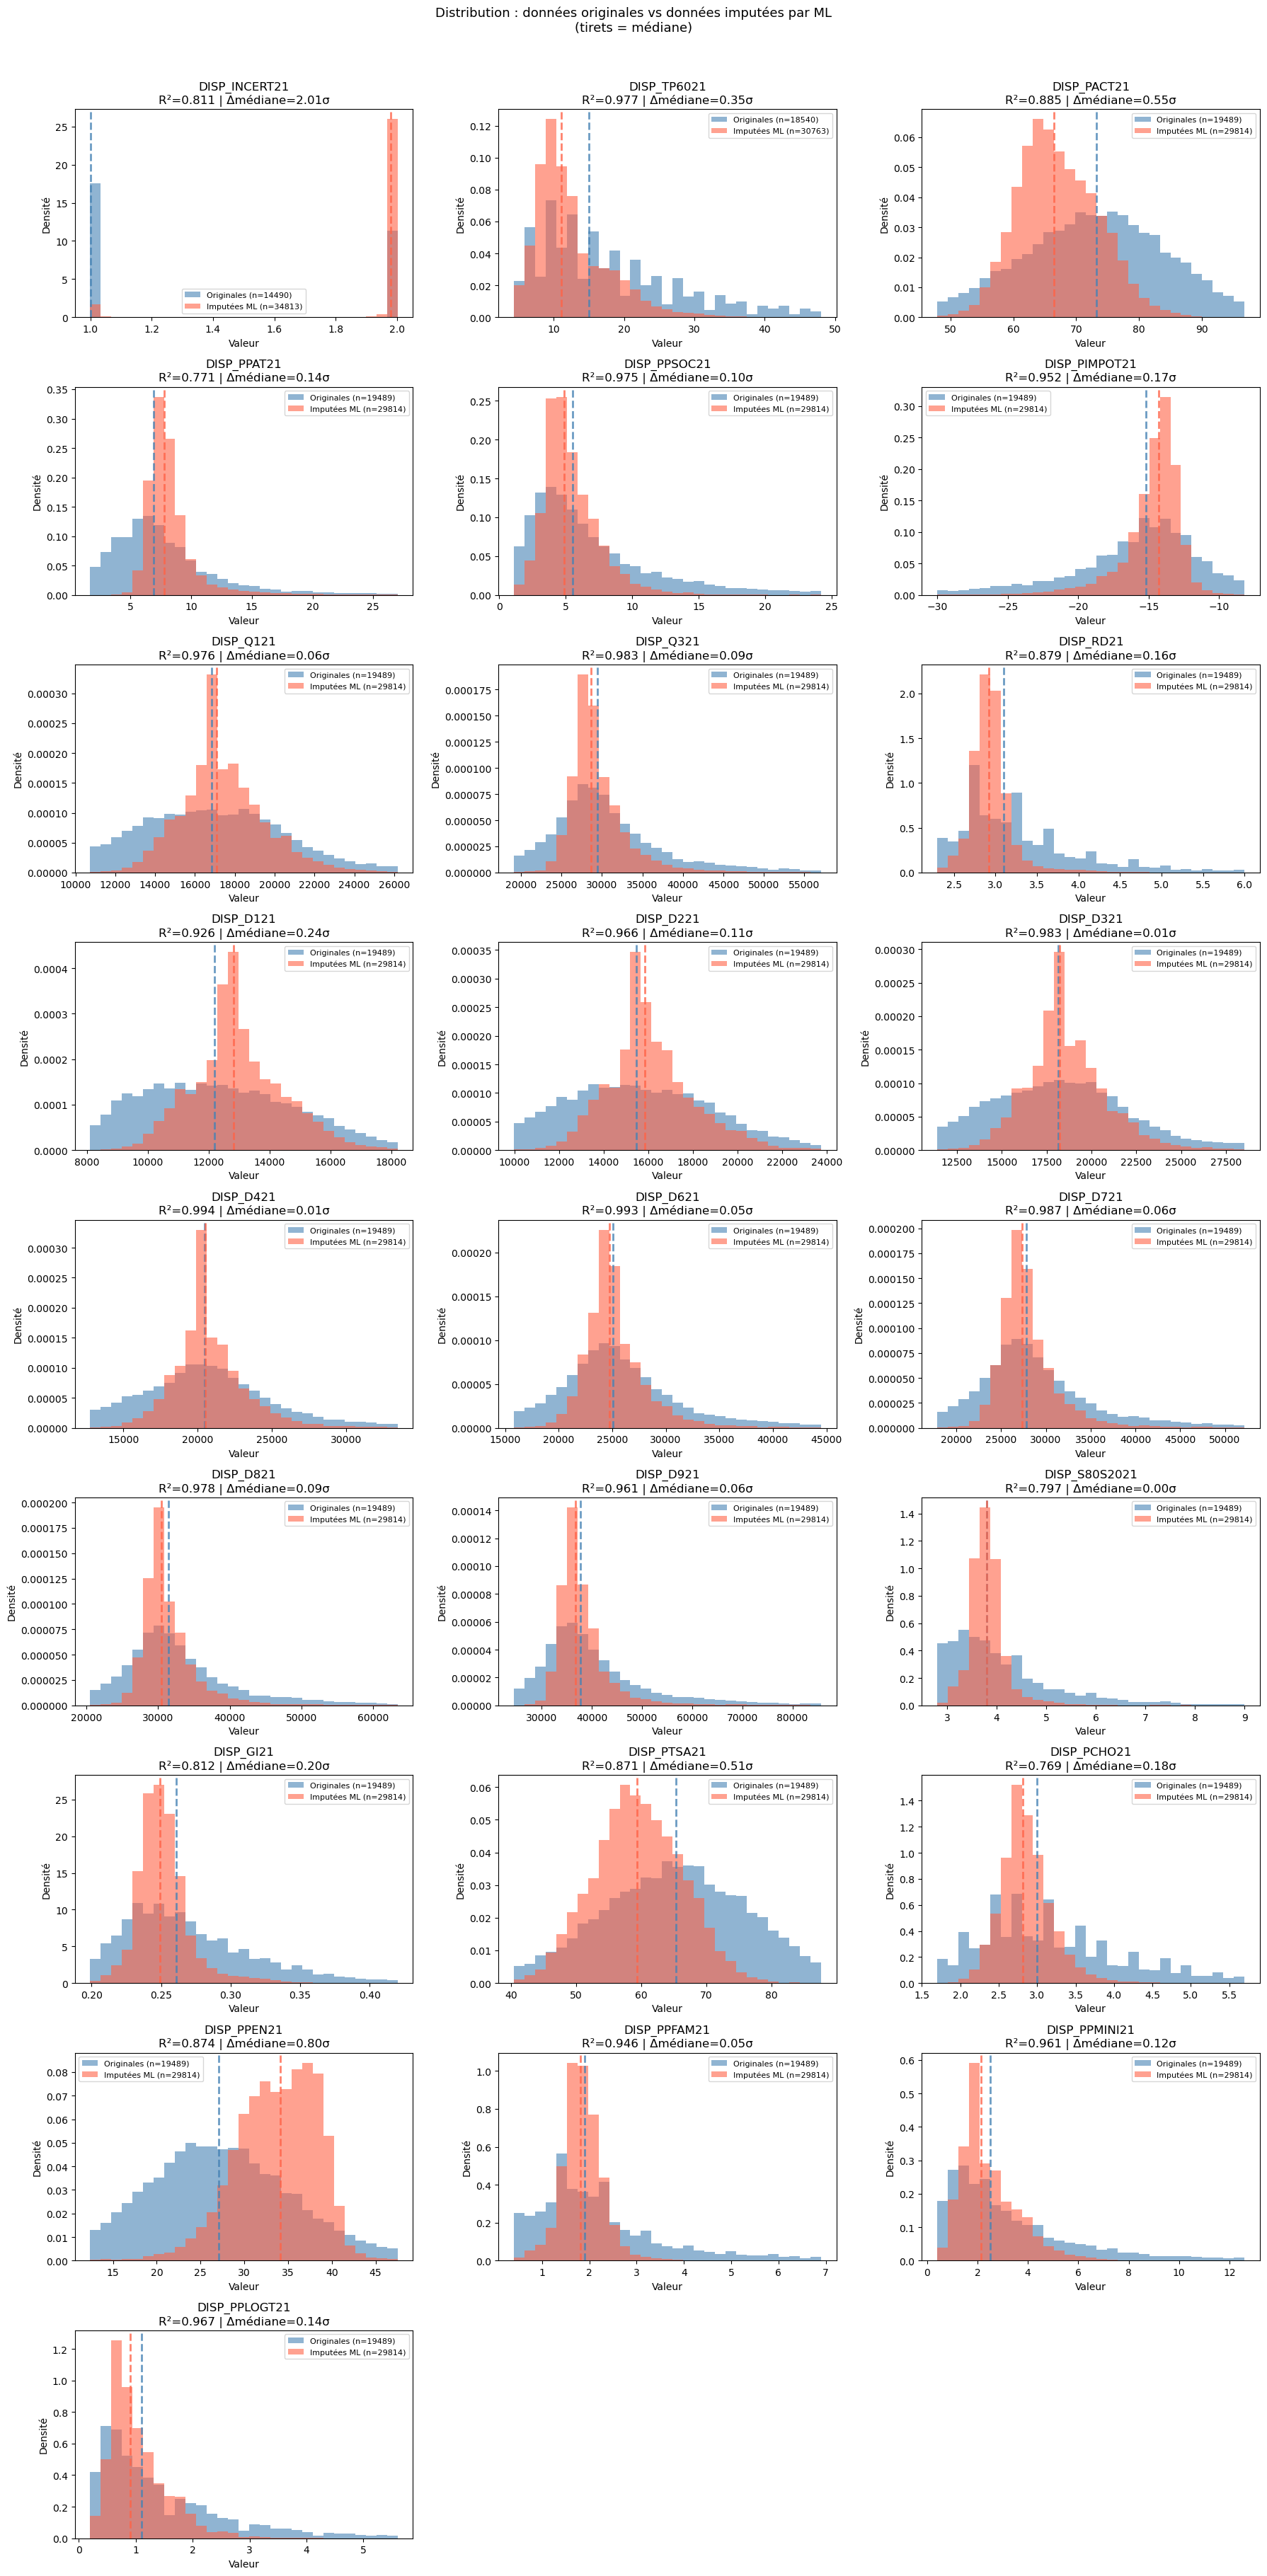

In [17]:
accepted_vars = [r['variable'] for r in ml_results if r['statut'] == 'ACCEPTÉ']
print(f"Variables imputées par ML (acceptées) : {accepted_vars}")

if not accepted_vars:
    print("Aucune variable imputée — rien à visualiser.")
else:
    n_vars = len(accepted_vars)
    n_cols = min(3, n_vars)
    n_rows = (n_vars + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
    if n_vars == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    
    for idx, var in enumerate(accepted_vars):
        row_i = idx // n_cols
        col_i = idx % n_cols
        ax = axes[row_i][col_i]
        
        mask_imputed  = imputation_masks[var]  # IRIS qui étaient NaN → imputés
        mask_original = ~mask_imputed & df_imputed[var].notna()
        
        vals_orig = df_imputed.loc[mask_original, var].dropna()
        vals_imp  = df_imputed.loc[mask_imputed,  var].dropna()
        
        if len(vals_orig) == 0 or len(vals_imp) == 0:
            ax.set_title(f"{var}\n(données insuffisantes)")
            continue
        
        # Histogrammes superposés
        all_vals = pd.concat([vals_orig, vals_imp])
        bins = np.linspace(all_vals.quantile(0.01), all_vals.quantile(0.99), 30)
        
        ax.hist(vals_orig, bins=bins, alpha=0.6, color='steelblue', label=f'Originales (n={len(vals_orig)})', density=True)
        ax.hist(vals_imp,  bins=bins, alpha=0.6, color='tomato',    label=f'Imputées ML (n={len(vals_imp)})', density=True)
        
        # Médianes
        ax.axvline(vals_orig.median(), color='steelblue', lw=2, ls='--', alpha=0.8)
        ax.axvline(vals_imp.median(),  color='tomato',    lw=2, ls='--', alpha=0.8)
        
        # Stats
        ks_stat = abs(vals_orig.median() - vals_imp.median()) / (vals_orig.std() + 1e-9)
        
        r2_info = next((r['r2'] for r in ml_results if r['variable'] == var), None)
        ax.set_title(f"{var}\nR²={r2_info:.3f} | Δmédiane={ks_stat:.2f}σ")
        ax.legend(fontsize=8)
        ax.set_xlabel('Valeur')
        ax.set_ylabel('Densité')
    
    # Masquer les axes vides
    for j in range(idx + 1, n_rows * n_cols):
        axes[j // n_cols][j % n_cols].set_visible(False)
    
    plt.suptitle("Distribution : données originales vs données imputées par ML\n(tirets = médiane)", 
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

## Étape 10 : Boxplots comparatifs + test KS statistique

Comparaison plus rigoureuse avec le test de Kolmogorov-Smirnov (distribution identique ?) et boxplots côte à côte.

C:\Users\vadim\AppData\Local\Temp\ipykernel_100836\1046882112.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(bp_data, labels=['Originales', 'Imputées ML'], patch_artist=True,
C:\Users\vadim\AppData\Local\Temp\ipykernel_100836\1046882112.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(bp_data, labels=['Originales', 'Imputées ML'], patch_artist=True,
C:\Users\vadim\AppData\Local\Temp\ipykernel_100836\1046882112.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(bp_data, labels=['Originales', 'Imputées ML'], patch_artist=True,
C:\Users\vadim\AppData\Local\Temp\

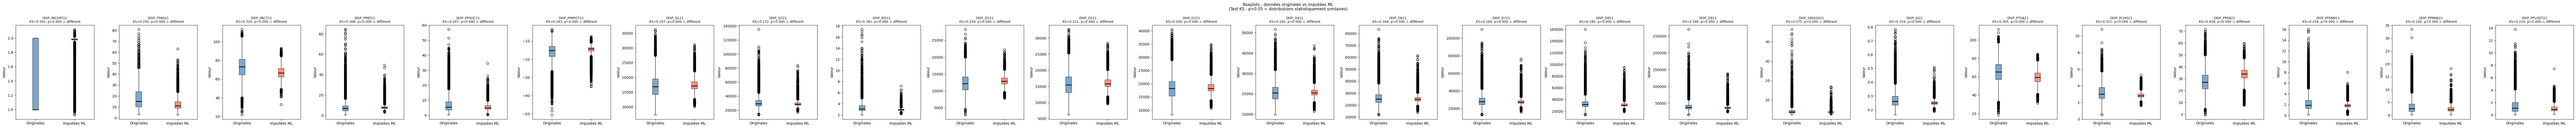


Résultats tests Kolmogorov-Smirnov :


,variable,ks_stat,ks_pval,distribution_similaire
0,DISP_INCERT21,0.591,0.000,False
1,DISP_TP6021,0.292,0.000,False
2,DISP_PACT21,0.325,0.000,False
3,DISP_PPAT21,0.366,0.000,False
4,DISP_PPSOC21,0.207,0.000,False
5,DISP_PIMPOT21,0.243,0.000,False
6,DISP_Q121,0.207,0.000,False
7,DISP_Q321,0.172,0.000,False
8,DISP_RD21,0.382,0.000,False
9,DISP_D121,0.254,0.000,False


In [18]:
from scipy import stats

if accepted_vars:
    fig, axes = plt.subplots(1, len(accepted_vars), figsize=(max(8, 4 * len(accepted_vars)), 5))
    if len(accepted_vars) == 1:
        axes = [axes]
    
    ks_results = []
    for i, var in enumerate(accepted_vars):
        ax = axes[i]
        mask_imputed  = imputation_masks[var]
        mask_original = ~mask_imputed & df_imputed[var].notna()
        
        vals_orig = df_imputed.loc[mask_original, var].dropna()
        vals_imp  = df_imputed.loc[mask_imputed,  var].dropna()
        
        # Test KS
        ks_stat, ks_pval = stats.ks_2samp(vals_orig, vals_imp)
        ks_results.append({'variable': var, 'ks_stat': round(ks_stat, 3), 'ks_pval': round(ks_pval, 4), 
                           'distribution_similaire': ks_pval > 0.05})
        
        # Boxplots
        bp_data = [vals_orig, vals_imp]
        bp = ax.boxplot(bp_data, labels=['Originales', 'Imputées ML'], patch_artist=True,
                        medianprops=dict(color='black', lw=2))
        bp['boxes'][0].set_facecolor('steelblue')
        bp['boxes'][0].set_alpha(0.7)
        bp['boxes'][1].set_facecolor('tomato')
        bp['boxes'][1].set_alpha(0.7)
        
        sig_marker = "✓ similaire" if ks_pval > 0.05 else "⚠ différent"
        ax.set_title(f"{var}\nKS={ks_stat:.3f}, p={ks_pval:.3f} {sig_marker}", fontsize=9)
        ax.set_ylabel('Valeur')
    
    plt.suptitle("Boxplots : données originales vs imputées ML\n(Test KS : p>0.05 = distributions statistiquement similaires)", fontsize=11)
    plt.tight_layout()
    plt.show()
    
    print("\nRésultats tests Kolmogorov-Smirnov :")
    df_ks = pd.DataFrame(ks_results)
    display(df_ks)

## Étape 11 : Heatmap globale de la couverture (vue d'ensemble)

Visualise d'un coup d'œil quelles variables sont disponibles pour quels IRIS.

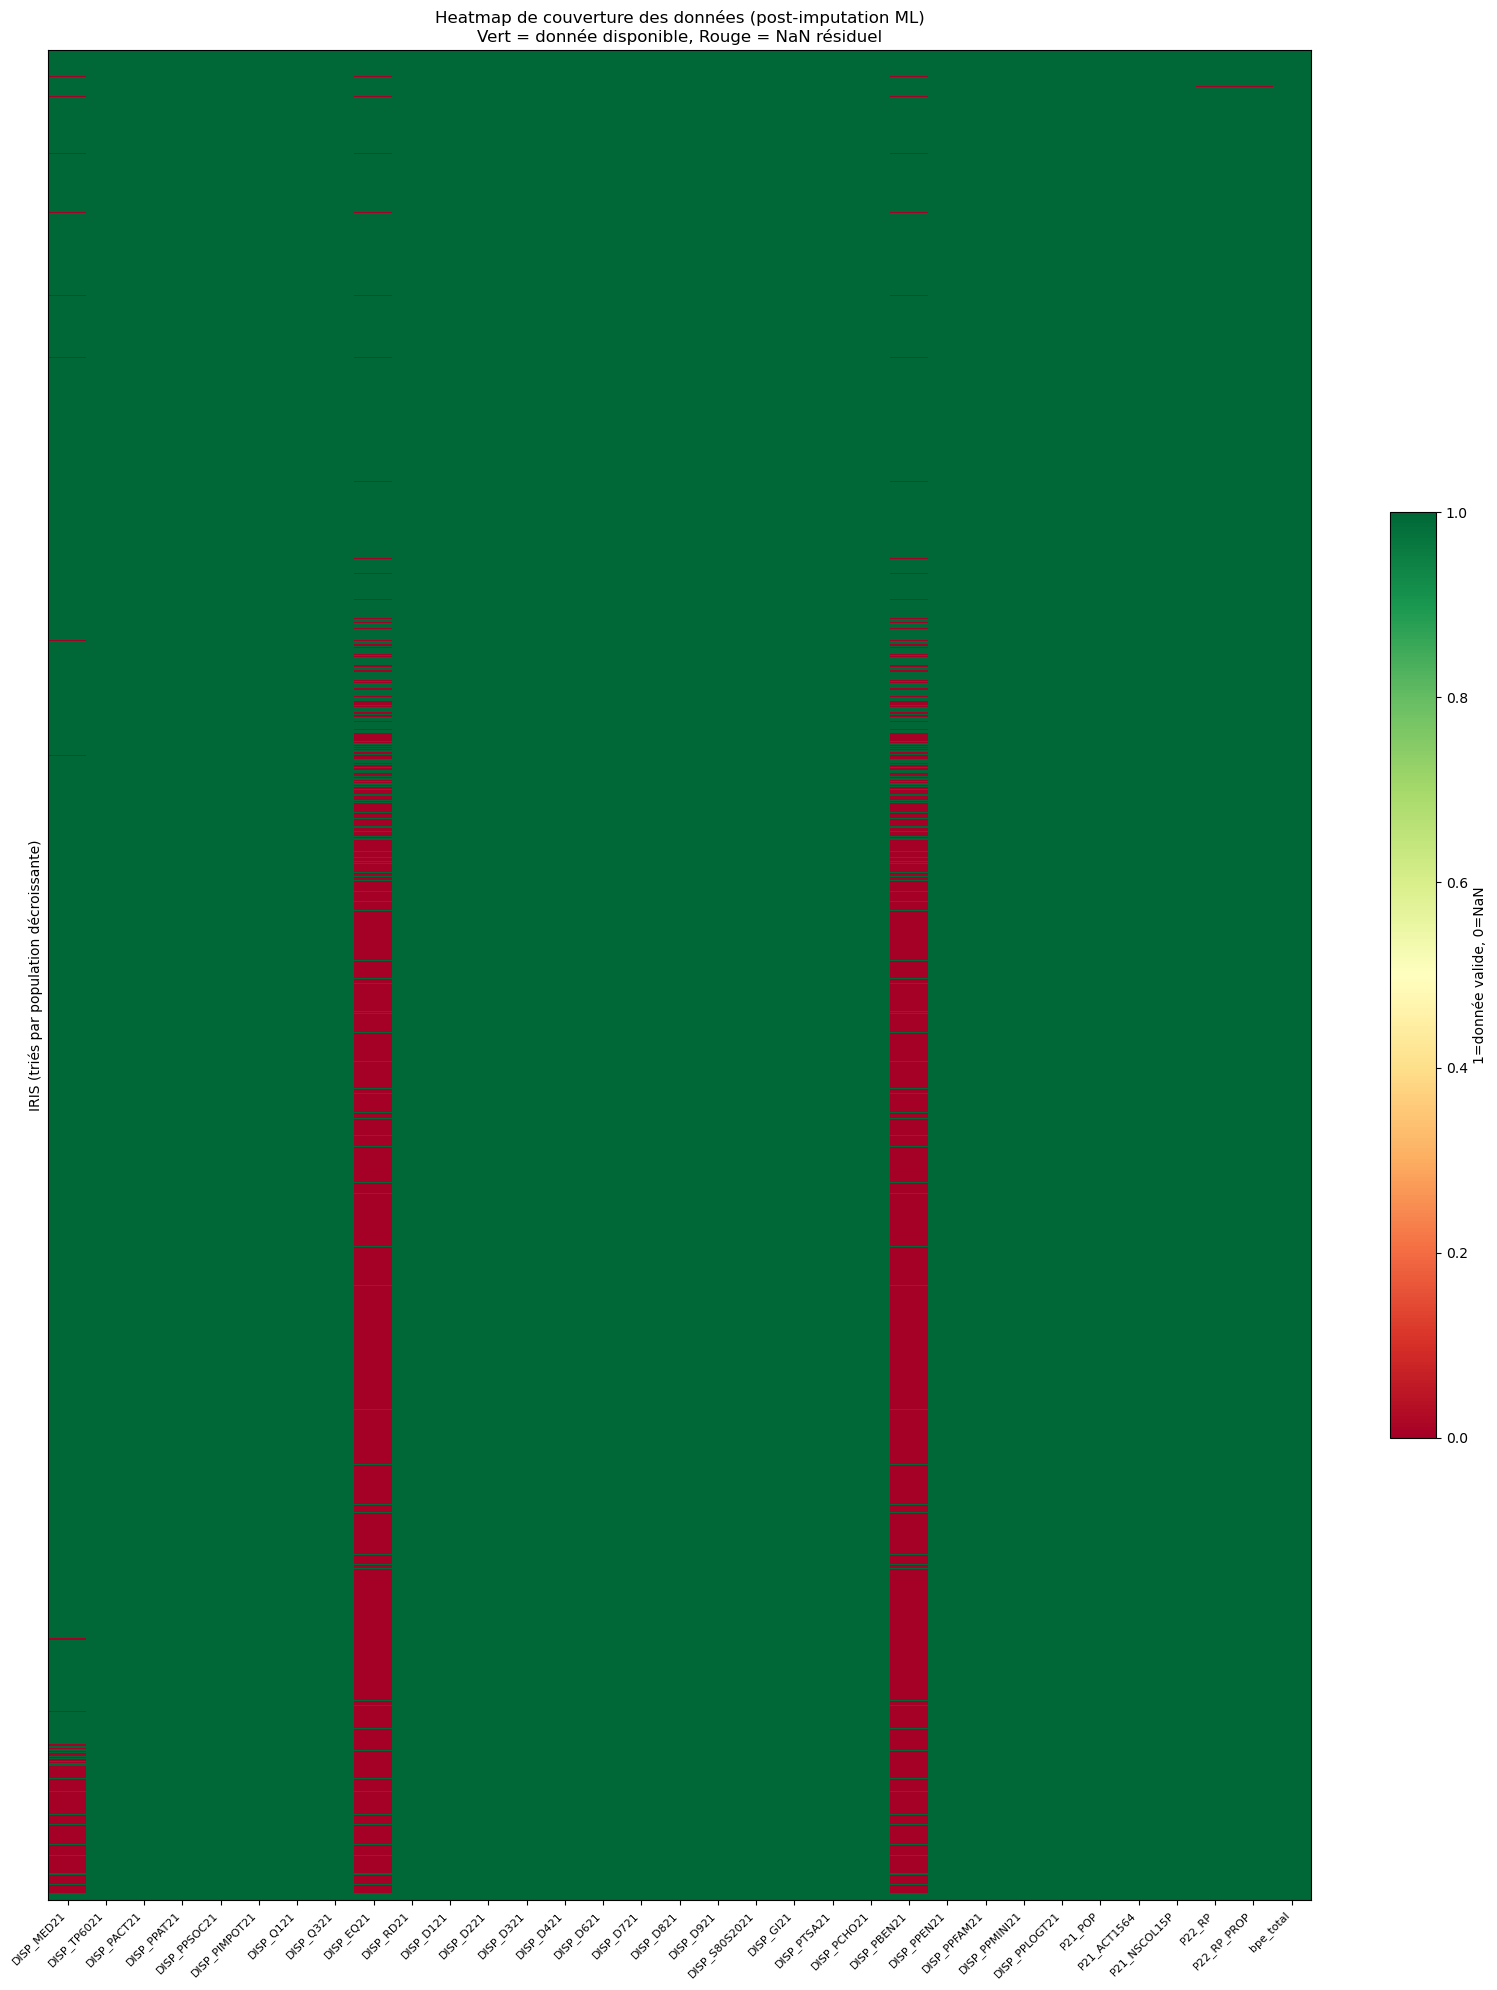


--- Couverture finale post-ML ---
  DISP_MED21                    : 45458/49303 (92.2%)
  DISP_TP6021                   : 49303/49303 (100.0%)
  DISP_PACT21                   : 49303/49303 (100.0%)
  DISP_PPAT21                   : 49303/49303 (100.0%)
  DISP_PPSOC21                  : 49303/49303 (100.0%)
  DISP_PIMPOT21                 : 49303/49303 (100.0%)
  DISP_Q121                     : 49303/49303 (100.0%)
  DISP_Q321                     : 49303/49303 (100.0%)
  DISP_EQ21                     : 19489/49303 (39.5%)
  DISP_RD21                     : 49303/49303 (100.0%)
  DISP_D121                     : 49303/49303 (100.0%)
  DISP_D221                     : 49303/49303 (100.0%)
  DISP_D321                     : 49303/49303 (100.0%)
  DISP_D421                     : 49303/49303 (100.0%)
  DISP_D621                     : 49303/49303 (100.0%)
  DISP_D721                     : 49303/49303 (100.0%)
  DISP_D821                     : 49303/49303 (100.0%)
  DISP_D921                     

In [25]:
# Variables à inclure dans la heatmap (DISP_* + quelques Census clés)
vars_heatmap = [v for v in COLS_TO_FILL if v in df_imputed.columns]
vars_heatmap += ['P21_POP', 'P21_ACT1564', 'P21_NSCOL15P', 'P22_RP', 'P22_RP_PROP', 'bpe_total']
vars_heatmap = [v for v in vars_heatmap if v in df_imputed.columns]

# Matrice binaire : 1 = donnée disponible, 0 = NaN
matrix = df_imputed[vars_heatmap].notna().astype(int)

# Trier les IRIS par population (les plus peuplés en haut)
if pop_col_audit in df_imputed.columns:
    sort_idx = df_imputed[pop_col_audit].fillna(0).argsort()[::-1]
    matrix = matrix.iloc[sort_idx.values]

fig, ax = plt.subplots(figsize=(max(10, len(vars_heatmap) * 0.5), min(20, len(matrix) * 0.05 + 3)))
im = ax.imshow(matrix.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1, interpolation='nearest')

ax.set_xticks(range(len(vars_heatmap)))
ax.set_xticklabels(vars_heatmap, rotation=45, ha='right', fontsize=8)
ax.set_ylabel("IRIS (triés par population décroissante)")
ax.set_yticks(df_imputed[pop_col_audit].fillna(0).argsort()[::-1])
ax.set_yticks([])
plt.colorbar(im, ax=ax, label='1=donnée valide, 0=NaN', shrink=0.5)
ax.set_title("Heatmap de couverture des données (post-imputation ML)\nVert = donnée disponible, Rouge = NaN résiduel")
plt.tight_layout()
plt.show()

# Stats finales
print("\n--- Couverture finale post-ML ---")
for var in vars_heatmap:
    n = df_imputed[var].notna().sum()
    total = len(df_imputed)
    print(f"  {var:<30}: {n}/{total} ({n/total*100:.1f}%)")

## Étape 12 : Analyse des IRIS qui restent sans données FILO après toutes les étapes

Qui sont les IRIS encore dans le flou ? Population, type, commune d'appartenance ?

IRIS sans DISP_MED21 (revenu médian) après tout le pipeline : 3845
  → 7.8% des IRIS
  → 917,632 habitants concernés (1.4% de la pop totale)

  Détail des IRIS sans données :


,IRIS,COM,LAB_IRIS,TYP_IRIS,P21_POP
48937,973110106,97311,1,H,15984.287
48909,973050102,97305,Z,H,13182.433
48916,973070102,97307,1,H,12361.529
48936,973110105,97311,1,H,10519.763
48619,971030105,97103,1,A,9867.478
...,...,...,...,...,...
48895,973020125,NaN,NaN,NaN,NaN
48896,973020126,NaN,NaN,NaN,NaN
48897,973020127,NaN,NaN,NaN,NaN
48910,973050103,NaN,NaN,NaN,NaN


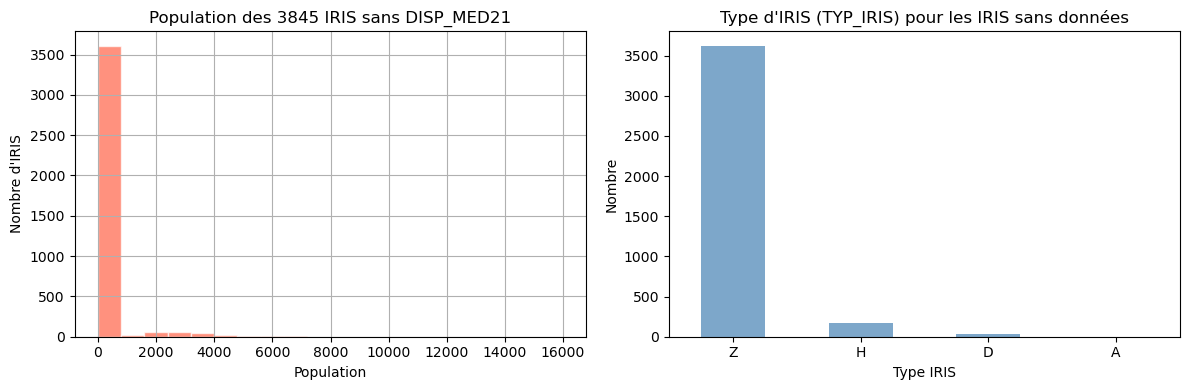

In [20]:
# IRIS encore sans DISP_MED21 (indicateur le plus important) après tout le pipeline
mask_no_med = df_imputed['DISP_MED21'].isna() if 'DISP_MED21' in df_imputed.columns else pd.Series(False, index=df_imputed.index)

iris_sans_filo = df_imputed[mask_no_med]
print(f"IRIS sans DISP_MED21 (revenu médian) après tout le pipeline : {len(iris_sans_filo)}")
print(f"  → {len(iris_sans_filo) / len(df_imputed) * 100:.1f}% des IRIS")

if len(iris_sans_filo) > 0:
    if pop_col_audit in iris_sans_filo.columns:
        pop_manquante = iris_sans_filo[pop_col_audit].sum()
        print(f"  → {pop_manquante:,.0f} habitants concernés ({pop_manquante / total_pop * 100:.1f}% de la pop totale)")
    
    cols_info = [c for c in ['IRIS', 'COM', 'LAB_IRIS', 'TYP_IRIS', pop_col_audit] if c in iris_sans_filo.columns]
    print(f"\n  Détail des IRIS sans données :")
    display(iris_sans_filo[cols_info].sort_values(pop_col_audit, ascending=False) if pop_col_audit in iris_sans_filo.columns else iris_sans_filo[cols_info])
    
    # Distribution des populations de ces IRIS
    if pop_col_audit in iris_sans_filo.columns:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
        
        iris_sans_filo[pop_col_audit].hist(ax=ax1, bins=20, color='tomato', alpha=0.7, edgecolor='white')
        ax1.set_title(f"Population des {len(iris_sans_filo)} IRIS sans DISP_MED21")
        ax1.set_xlabel("Population")
        ax1.set_ylabel("Nombre d'IRIS")
        
        if 'TYP_IRIS' in iris_sans_filo.columns:
            iris_sans_filo['TYP_IRIS'].value_counts().plot(kind='bar', ax=ax2, color='steelblue', alpha=0.7)
            ax2.set_title("Type d'IRIS (TYP_IRIS) pour les IRIS sans données")
            ax2.set_xlabel("Type IRIS")
            ax2.set_ylabel("Nombre")
            ax2.tick_params(axis='x', rotation=0)
        
        plt.tight_layout()
        plt.show()
else:
    print("  → Tous les IRIS ont une valeur DISP_MED21 !")